<a href="https://colab.research.google.com/github/Medder001/ML-Final/blob/main/ML_Final_Kay%26Megan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)
DRIVE_PATH = "/content/drive/MyDrive/archive"


Mounted at /content/drive


In [3]:
import os
import numpy as np
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
def load_images(folder, label, img_size=(64, 64), max_images=1000):
  data = []
  filenames = os.listdir(folder)
  np.random.shuffle(filenames)
  count = 0
  for fname in filenames:
    if count >= max_images:
      break
    try:
      img = Image.open(os.path.join(folder, fname)).convert('RGB')
      img = img.resize(img_size)
      pixels = np.array(img)
      data.append({'pixels': pixels, 'label':label})
      count += 1
    except Exception:
      pass
  return data

In [5]:
ai_data = load_images("/content/drive/MyDrive/archive/AiArtData/AiArtData", label=1)
real_data = load_images("/content/drive/MyDrive/archive/RealArt/RealArt", label = 0)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [6]:
df = pd.DataFrame(ai_data + real_data)

X = np.stack(df['pixels'].values)
y = df['label'].values

In [7]:
print(f"Total instance: {len(df)}")
print(df['label'].value_counts())

size_mb = df['pixels'].apply(lambda x: x.nbytes).sum() / (1024 * 1024)
print(f"Loaded data size: {size_mb:.2f} MB")


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X.shape)
print(X.dtype)

Total instance: 949
label
1    526
0    423
Name: count, dtype: int64
Loaded data size: 11.12 MB
(949, 64, 64, 3)
uint8


Our dataset is sampled for an AI-generated image detector ML model from Kaggle (https://www.kaggle.com/datasets/cashbowman/ai-generated-images-vs-real-images).
We sample up to 1,000 images per class with a result of 975 image instances in our dataset, specifically 539 AI-generated images and 436 real images. The images are resized to 64x64 and formatted as 'RGB'. From this, the calculated number of numeric attributes is 64 * 64 * 3 = 12,288 which are normalized to a continuous range of [0,1]. Additonally, any corrupted files are passed over.

In [8]:
# This will not be used for anything but part 2 required it.
# The CNN needs our data to have dimensionality

X_flat = X.reshape(len(X), -1)

print(X.shape)
print(X_flat.shape)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_flat)

print(X_pca.shape)
print(pca.explained_variance_ratio_.sum())
print(pca.n_components_)

(949, 64, 64, 3)
(949, 12288)
(949, 355)
0.950036113530047
355


In [9]:
# You will have to run this before you train every time or it will train the
# already trained model.

model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 388,289 (1.48 MB)

 Trainable params: 388,289 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=28,
    validation_split=0.15,
    callbacks=[early_stopping]
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 425ms/step - accuracy: 0.5442 - loss: 0.6981 - val_accuracy: 0.5351 - val_loss: 0.6927
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.5581 - loss: 0.6834 - val_accuracy: 0.5351 - val_loss: 0.6897
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 263ms/step - accuracy: 0.5581 - loss: 0.6675 - val_accuracy: 0.5351 - val_loss: 0.6698
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.5612 - loss: 0.6705 - val_accuracy: 0.5351 - val_loss: 0.6579
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.5907 - loss: 0.6545 - val_accuracy: 0.5439 - val_loss: 0.6567
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 257ms/step - accuracy: 0.5969 - loss: 0.6536 - val_accuracy: 0.6316 - val_loss: 0.6629
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.5643 - loss: 0.6603 - val_accuracy: 0.6053 - val_loss: 0.6540
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - accuracy: 0.6155 - loss: 0.6398 - val_accuracy: 0

In [11]:
val_loss, val_acc = model.evaluate(X_test, y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6947 - loss: 0.6184


In [13]:
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).ravel()


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix: ")
print(cm)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step
Confusion Matrix: 
[[50 35]
 [23 82]]


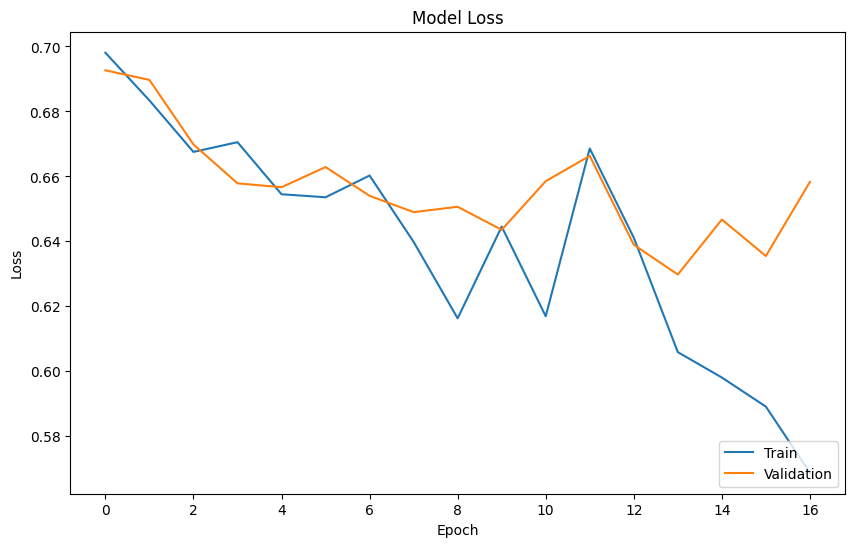

In [14]:
plt.figure(figsize = (10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

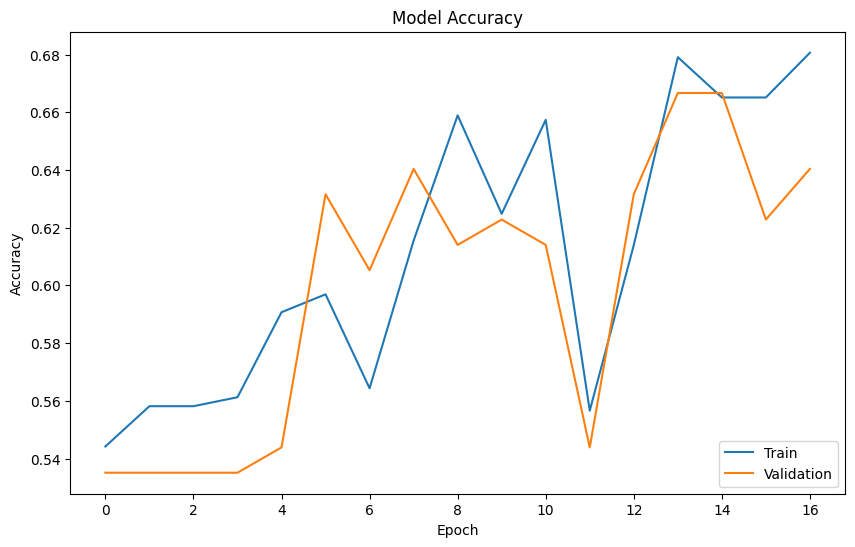

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()